In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.DataFrame({
    'CustomerID'      : range(1, 201),
    'Gender'          : np.random.choice(['Male', 'Female'], 200),
    'Age'             : np.random.randint(18, 70, 200),
    'Annual_Income'   : np.random.randint(15, 137, 200),
    'Spending_Score'  : np.random.randint(1, 100, 200)
})
print(df.columns.tolist())
print(df.shape)
print(df.isnull().sum())
print(df.head(5))
print(df.describe())

['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
(200, 5)
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64
   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1  Female   40             21               6
1           2    Male   60             82              25
2           3    Male   62             77              52
3           4    Male   64            118              20
4           5  Female   53            118              72
       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   43.875000      75.325000       51.180000
std     57.879185   14.536365      34.910357       29.205348
min      1.000000   18.000000      15.000000        1.000000
25%     50.750000   33.000000      46.000000       25.000000
50%    100.500000   43.500000      73.500000       52.500000
75%    150.250000   56.000000     10

In [ ]:
df=df.drop('CustomerID',axis=1)
features=['Age','Annual_Income','Spending_Score']
x=df[features]
print(x.shape)
print(x.head(5))

(200, 3)
   Age  Annual_Income  Spending_Score
0   40             21               6
1   60             82              25
2   62             77              52
3   64            118              20
4   53            118              72


In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print(x.describe().round(2))
print(pd.DataFrame(x_scaled,columns=features).describe().round(2))

          Age  Annual_Income  Spending_Score
count  200.00         200.00          200.00
mean    43.88          75.32           51.18
std     14.54          34.91           29.21
min     18.00          15.00            1.00
25%     33.00          46.00           25.00
50%     43.50          73.50           52.50
75%     56.00         103.25           76.50
max     69.00         136.00           99.00
          Age  Annual_Income  Spending_Score
count  200.00         200.00          200.00
mean     0.00          -0.00            0.00
std      1.00           1.00            1.00
min     -1.78          -1.73           -1.72
25%     -0.75          -0.84           -0.90
50%     -0.03          -0.05            0.05
75%      0.84           0.80            0.87
max      1.73           1.74            1.64


In [ ]:
inertia=[]
k_range=range(1,11)
for k in k_range:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)

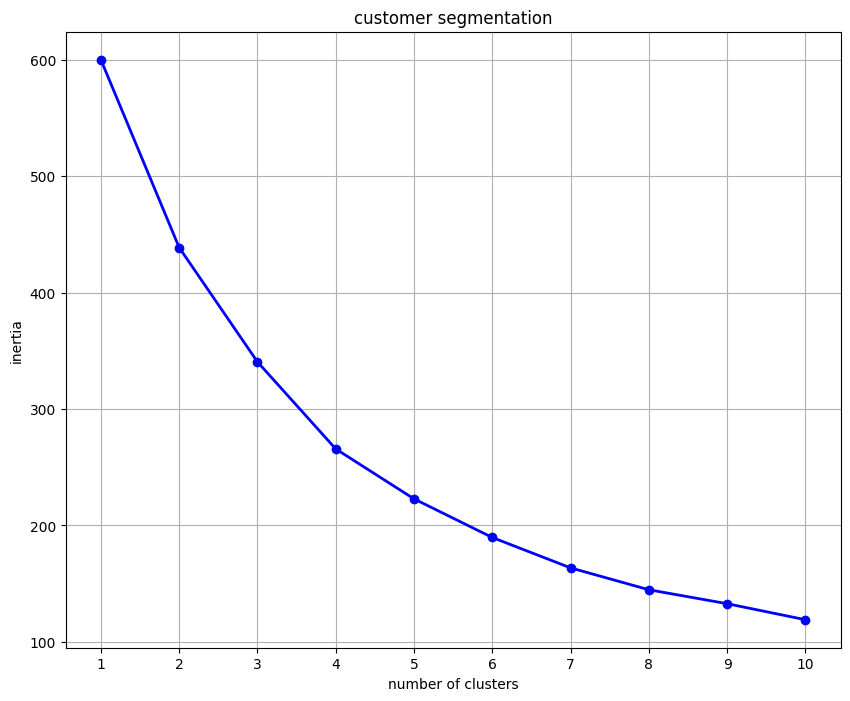

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(k_range,inertia,'bo-',linewidth=2)
plt.title('customer segmentation')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
for k,inertia in zip(k_range,inertia):
  print(f"k= {k} inertai= {inertia}")

k= 1 inertai= 599.9999999999998
k= 2 inertai= 438.68407027669633
k= 3 inertai= 340.4741355705448
k= 4 inertai= 265.6958495801885
k= 5 inertai= 222.7835053533299
k= 6 inertai= 189.62042781043777
k= 7 inertai= 163.52410293660267
k= 8 inertai= 144.72383342608782
k= 9 inertai= 132.73972604001668
k= 10 inertai= 118.97831148479673


In [ ]:
silhouette=[]
k_range=range(2,11)
for k in k_range:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  predict=kmeans.fit_predict(x_scaled)
  score=silhouette_score(x_scaled,predict)
  silhouette.append(score)
  print(f" k = {k} silhouette score= {score}:.4f")

 k = 2 silhouette score= 0.25314783606733526:.4f
 k = 3 silhouette score= 0.2568639715086624:.4f
 k = 4 silhouette score= 0.29028858040940586:.4f
 k = 5 silhouette score= 0.28952192421766737:.4f
 k = 6 silhouette score= 0.2902921125692483:.4f
 k = 7 silhouette score= 0.3014045135647073:.4f
 k = 8 silhouette score= 0.3037236270421427:.4f
 k = 9 silhouette score= 0.29033293939512833:.4f
 k = 10 silhouette score= 0.311868863848452:.4f


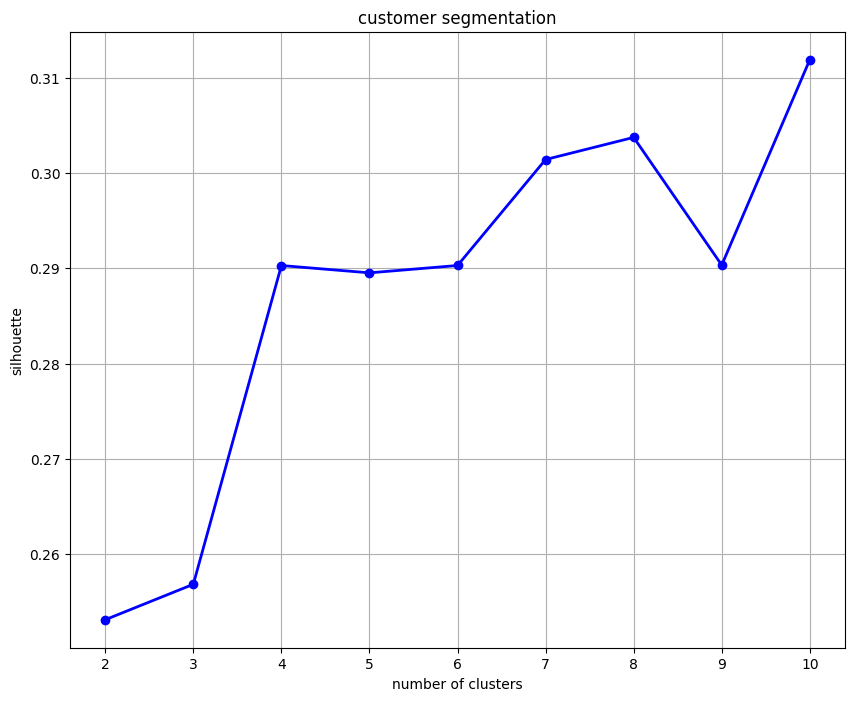

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(k_range,silhouette,'bo-',linewidth=2)
plt.title('customer segmentation')
plt.xlabel('number of clusters')
plt.ylabel('silhouette')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['cluster']=kmeans.fit_predict(x_scaled)
print(df['cluster'].value_counts().sort_index())
print(df.groupby('cluster')[features].mean().round(4))

cluster
0    58
1    34
2    37
3    28
4    43
Name: count, dtype: int64
             Age  Annual_Income  Spending_Score
cluster                                        
0        44.8448        39.8448         63.7069
1        58.9706        98.9412         77.9118
2        55.5676        94.0541         22.3784
3        31.5357       104.5357         76.2500
4        28.6047        69.3721         21.6047


explained varaince ratio: 0.71


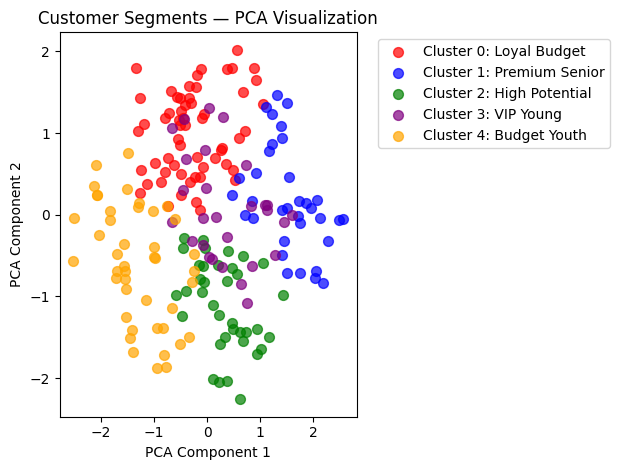

In [ ]:
pca=PCA(n_components=2,random_state=42)
x_pca=pca.fit_transform(x_scaled)
print(f"explained varaince ratio: {pca.explained_variance_ratio_.sum():.2f}")
colors = ['red', 'blue', 'green', 'purple', 'orange']
cluster_names = ['Loyal Budget', 'Premium Senior',
                 'High Potential', 'VIP Young',
                 'Budget Youth']
for cluster in range(5):
    mask = df['cluster'] == cluster
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1],
                c=colors[cluster],
                label=f'Cluster {cluster}: {cluster_names[cluster]}',
                s=50, alpha=0.7)

plt.title('Customer Segments — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()